# CSE2530 Computational Intelligence
## Assignment 1: Ant Colony Optimization and Genetic Algorithms

|    Group   |           13          |
|------------|----------------------|
| Bram Clarenbeek  |        6240089   |
| Ivan 't Hart  |      6135366         |
| Shi-Yan Wassens  |        6191789      |
| Georgi Georgiev  |      6182038        |


#### Imports

In [11]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import numpy as np
import random
import sys
import time

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Coordinate import Coordinate
from Direction import Direction
from PathSpecification import PathSpecification
from Route import Route
from SurroundingPheromone import SurroundingPheromone
from TSPData import TSPData

## Part 1: The Travelling Robot Problem
### 1.1 Problem Analysis
#### Question 1:

Q: **Look into the literature and explain how the TSP problem is usually defined.**

A: The Travelling Salesman Problem is an optimization problem where, given n cities and the distance between every pair of cities, the goal is to find the shortest possible route that visits each city exactly once and returns to the starting city.

https://en.wikipedia.org/wiki/Travelling_salesman_problem

#### Question 2

Q: **In a classic TSP, all cities (nodes) are singularly connected to all other nodes and relative distances are known and symmetric (a weighted complete graph). Give three ways
in which our problem is different.**

A:
1. Non-Euclidean distances. Walls block paths, which means that two close products can still be far apart in walking distance.
2. Distances must be computed. Pairwise distances aren't given, so the ACO must calculate them before the GA can run.
3. Output is an action sequence. In classic TSP you only need to decide the order to visit locations, but here the robot also needs exact step by step directions to get there.

#### Question 3

Q: **Why are computational intelligence techniques appropriate to solve the TSP? What
are the characteristics which let us to tackle typically intractable problems?**

A:
CI techniques are appropriate for TSP because the number of possible routes grows extremely fast (20 products already gives 20!=2.432902e+18 possibilities), making it nearly impossible to bruteforce. 
CI techniques handles this through some key characteristics of which we have listed two:

1. Heuristic search. instead of trying every possible solution, they explore only the most promising ones which saves a lot of computation time.
2. Accepting good enough solutions. They don't guarantee the perfect solution, but still try to find a very good one in a reasonable amount of time, which is usually good enough in practice.

### 1.2 Genetic Algorithm

In [12]:
# TSP problem solver using genetic algorithms.
class GeneticAlgorithm:

    """
    Constructs a new 'genetic algorithm' object.
    @param generations: the amount of generations.
    @param pop_size: the population size.
    """
    def __init__(self, generations, pop_size):
        self.generations = generations
        self.pop_size = pop_size
    
    """
    This method should solve the TSP.
    @param tsp_data: the data describing the problem.
    @return the optimized product sequence.
    """
    def solve_tsp(self, tsp_data):
        # Find the distances between all pairs of products
        # and the distances from the start to each product and from each product to the end.
        distances = tsp_data.get_distances()
        start_distances = tsp_data.get_start_distances()
        end_distances = tsp_data.get_end_distances()
        n = len(distances)

        # Initialize the population with random routes and finds the one with the shortest length to start with.
        population = []
        for _ in range(self.pop_size):
            individual = list(np.random.permutation(n))
            population.append(individual)
        best = self.get_best(population, distances, start_distances, end_distances)

        # Evolve the population for a certain number of generations.
        # Each evolution consists of:
        # 1) Creating a new population by selecting parents using tournament selection
        # 2) Performing crossover to create children
        # 3) Mutating the children.
        for generation in range(self.generations):
            new_population = [best.copy()]  

            while len(new_population) < self.pop_size:
                parent1 = self.tournament_select(population, distances, start_distances, end_distances)
                parent2 = self.tournament_select(population, distances, start_distances, end_distances)
                child = self.order_crossover(parent1, parent2)
                child = self.mutate(child)
                new_population.append(child)

            population = new_population
            current_best = self.get_best(population, distances, start_distances, end_distances)
            current_best_length = self.route_length(current_best, distances, start_distances, end_distances)
            best_length = self.route_length(best, distances, start_distances, end_distances)
            if current_best_length < best_length:
                best = current_best
                
        return best

    """
    This method returns the best route in the population.
    @param population: the population of routes.
    @param distances: the distances between all pairs of products.
    @param start_distances: the distances from the start to each product.
    @param end_distances: the distances from each product to the end.
    @return the best route in the population.
    """
    def get_best(self, population, distances, start_distances, end_distances):
        best = population[0]
        for individual in population:
            if self.route_length(individual, distances, start_distances, end_distances) < self.route_length(best, distances, start_distances, end_distances):
                best = individual
        return best

    """
    This method returns the length of a route.
    @param self: the object itself.
    @param individual: the route for which to calculate the length.
    @param distances: the distances between all pairs of products.
    @param start_distances: the distances from the start to each product.
    @param end_distances: the distances from each product to the end.
    @return the length of the route.
    """
    def route_length(self, individual, distances, start_distances, end_distances):
        total = start_distances[individual[0]]
        for i in range(len(individual) - 1):
            total += distances[individual[i]][individual[i + 1]]
        total += end_distances[individual[len(individual)- 1]]
        return total

    """
    This method uses a tournament selection to select a parent from the population.
    This tournament selection works by randomly selecting k (default k = 5) individuals from the population and returning the best one among them.
    @param self: the object itself.
    @param population: the population of routes.
    @param distances: the distances between all pairs of products.
    @param start_distances: the distances from the start to each product.
    @param end_distances: the distances from each product to the end.
    @param k: the number of individuals to select for the tournament (default = 5).
    @return the selected parent route.
    """
    def tournament_select(self, population, distances, start_distances, end_distances, k=5):
        candidates = np.random.choice(len(population), k)
        best_candidate = candidates[0]
        for i in candidates:
            if self.route_length(population[i], distances, start_distances, end_distances) < self.route_length(population[best_candidate], distances, start_distances, end_distances):
                best_candidate = i
        return population[best_candidate]

    """
    This method finds the cross-over between two parents using the order crossover method.
    @param self: the object itself.
    @param parent1: the first parent route.
    @param parent2: the second parent route.
    @return the child route resulting from the crossover.
    """
    def order_crossover(self, parent1, parent2):
        size = len(parent1)

        point1 = np.random.randint(0, size)
        point2 = np.random.randint(0, size)
        if point1 > point2:
            point1, point2 = point2, point1
        
        child = [-1] * size
        for i in range(point1, point2 + 1):
            child[i] = parent1[i]
        
        fill = []
        for x in parent2:
            if x not in child:
                fill.append(x)
        
        fill_idx = 0
        for i in range(size):
            if child[i] == -1:
                child[i] = fill[fill_idx]
                fill_idx += 1
        
        return child

    """
    This method mutates a route by swapping two random products with a certain mutation rate.
    @param self: the object itself.
    @param individual: the route to mutate.
    @param mutation_rate: the probability of mutating each product (default = 0.1).
    @return the mutated route.
    """
    def mutate(self, individual, mutation_rate=0.1):
        individual = individual.copy()
        for i in range(len(individual)):
            if np.random.random() < mutation_rate:
                j = np.random.randint(len(individual))
                temp = individual[i]
                individual[i] = individual[j]
                individual[j] = temp
        return individual

#### Question 4

Q: **What do the genes represent? How will you encode your chromosomes?**

A:
Each gene is a product to visit and a chromosome is encoded as a list of products where the order represents the sequence in which the robot goes to each product.

#### Question 5

Q: **Which fitness function will you use? Why is this a suitable choice?**

The fitness function is the total route length with shorter routes having better fitness. This works since it directly measures what we want to minimize.

#### Question 6

Q: **How are parents selected from the population?**

Parents are selected using tournament selection where 5 random individuals are picked from the population and the one with the shortest route is selected as a parent.

#### Question 7

Q: **What genetic operations did you implement? What are their functions (goals)?**

A:
We first implemented order-crossover, which can be compared to two parents getting a child. In order-crossover, we take segments from one parent and fill the remaining positions with the order of the other parent, creating a valid child route.
We then implemented mutation, which randomly mutates some parts of the found children, this helps our algorithm to not get stuck in local minima and introduces more diversity.

Together, they will find good solutions by crossing over already good solutions, while still exploring new possibilities by mutating.

#### Question 8

Q: **How do you prevent local minima?**

A: As explained before, we prevent local minima by adding mutation. When crossover keeps focussing on a good solution, the mutation will help it explore new possibilities to make sure it still can find an even better solution.

#### Question 9

Q: **What is elitism? Have you applied it? Why (not)?**

A: Elitism is a way of keeping track of the currently best solution. We have applied this: we keep track of the best route so far, and every new population has the best route so far in it. Then after selecting, if there is an even better route, we make sure that is in the next population and so on. Doing this allows the algorithm to never lose the best route so far and will make the next population have a best route that is at least as good as the last population's best route.

#### Question 10

In [13]:
# Please keep your parameters for the Genetic Algorithm easily changeable here
np.random.seed(42)
population_size = 100
generations = 100
persist_file = "./../data/optimal_tsp"

# Setup optimization
tsp_data = TSPData.read_from_file(persist_file)
ga = GeneticAlgorithm(generations, population_size)

best_solution = None
best_length = float('inf')
best_params = (0, 0)

# Loop over population sizes and generations (10 to 100 in steps of 10)
for current_population_size in range(10, population_size, 10):
    for current_generations in range(10, generations, 10):
        # Setup GA
        ga = GeneticAlgorithm(current_generations, current_population_size)
        
        # Solve TSP
        solution = ga.solve_tsp(tsp_data)
        
        # Compute solution length
        solution_length = ga.route_length(
            solution,
            tsp_data.get_distances(),
            tsp_data.get_start_distances(),
            tsp_data.get_end_distances()
        )
        
        if solution_length < best_length:
            best_length = solution_length
            best_solution = solution
            best_params = (current_population_size, current_generations)
            print(f"New best! Population_size/Generations = {current_population_size}/{current_generations}, Solution Length = {solution_length}")

tsp_data.write_action_file(best_solution, "./../data/tsp_solution.txt")

New best! Population_size/Generations = 10/10, Solution Length = 3563
New best! Population_size/Generations = 10/20, Solution Length = 2537
New best! Population_size/Generations = 10/30, Solution Length = 2495
New best! Population_size/Generations = 10/40, Solution Length = 2305
New best! Population_size/Generations = 10/50, Solution Length = 2173
New best! Population_size/Generations = 20/30, Solution Length = 1779
New best! Population_size/Generations = 20/70, Solution Length = 1597
New best! Population_size/Generations = 20/80, Solution Length = 1347
New best! Population_size/Generations = 40/60, Solution Length = 1325


In [14]:
# REMOVE BEFORE HANDING IN. ONLY USED FOR VISUALIZATION OF THE GA SOLUTION.

from VisualizerHelpers import Maze
from Visualizer import Visualizer
from PathSpecification import PathSpecification
from TSPData import TSPData

# Load the maze
maze = Maze.create_maze("./../data/hard_maze.txt")

# Load TSP data
tsp_data = TSPData.read_from_file("./../data/optimal_tsp")

# Your GA solution from before
solution = ga.solve_tsp(tsp_data)

# Visualize the full route step by step
for i in range(len(solution) - 1):
    start_idx = solution[i]
    end_idx = solution[i + 1]

    # Create a PathSpecification for this segment
    spec = PathSpecification(tsp_data.product_locations[start_idx],
                             tsp_data.product_locations[end_idx])

    # Get the precomputed route (from TSP data)
    route = tsp_data.product_to_product[start_idx][end_idx]

    # Visualize this segment

    #UNCOMMENT THIS TO SEE ALL INDIVIDUAL PATHS
    #Visualizer.visualize_individual_path(maze, route, spec)

Ready reading maze file ./../data/hard_maze.txt


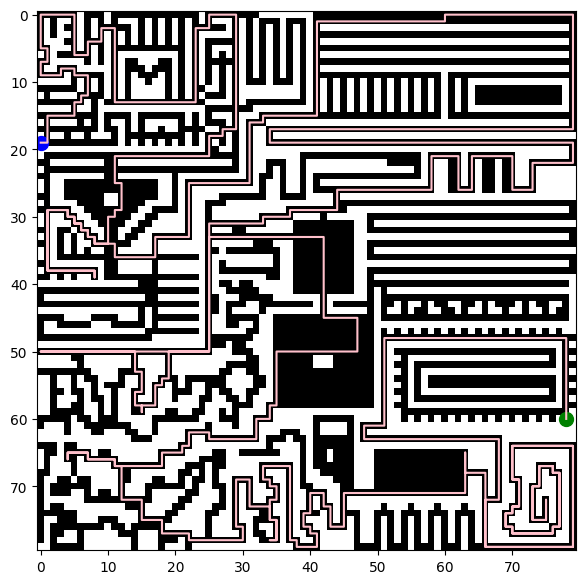

In [15]:
# REMOVE BEFORE HANDING IN. ONLY USED FOR VISUALIZATION OF THE GA SOLUTION.

# Now the full visualization of the entire route in one go.

full_route = Route(tsp_data.product_locations[solution[0]])

# Append all directions from each segment
for i in range(len(solution) - 1):
    segment = tsp_data.product_to_product[solution[i]][solution[i + 1]]  # Route object
    for direction in segment.get_route():
        full_route.add(direction)

# Visualize as a single path
Visualizer.visualize_individual_path(
    maze,
    full_route,
    PathSpecification(
        tsp_data.product_locations[solution[0]],
        tsp_data.product_locations[solution[-1]]
    )
)

Q: **Apply your algorithm to find the shortest route using the provided data. What is the
length of your solution? Is it optimal?**

A: We decided to go over different sizes of generations and populations. For both we went from 10 to 100 in steps of 10. After a population size of 40 and 60 generations, we found a path length of 1325, which is the best we found. Of course we can't guarantee optimality but it seems to be near-optimal.

## Part 2: Path Finding Through Ant Colony Optimization
### 2.2 Observing the Problem

#### Question 11

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 12

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 13

<div style="background-color:#f1be3e">

_Write your answer here. You can also use LaTeX notation in a Jupyter Notebook._

#### Question 14

<div style="background-color:#f1be3e">

_Write your answer here. You can also use LaTeX notation in a Jupyter Notebook._

### 2.3 Implementing the Ant Algorithm

In [16]:
# Class that represents the basic Ant functionality
class StandardAnt:

    """
    Constructor of a StandardAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.rand = random

    """
    Method that performs a single complete run through the maze by the ant
    @return the route found by the ant
    """
    def find_route(self):
        route = Route(self.start)
        pass


In [17]:
# Class that holds all of the maze data.
# This includes the pheromones, the open and blocked tiles in the system,
# and the starting and end coordinates for the ants.
class Maze:

    """
    Constructor of a Maze
    @param walls: array of ints representing the accessible (1) and inaccessible (0) tiles
    @param width: the width (horizontal dimension) of the Maze
    @param length: the length (vertical dimension) of the Maze
    """
    def __init__(self, walls, width, length):
        self.walls = walls
        self.length = length
        self.width = width
        self.start = None
        self.end = None
        self.initialize_pheromones()

    """
    Initialize pheromones on all tiles of the Maze
    """
    def initialize_pheromones(self):
        pass

    """
    Reset the Maze for a new shortest path problem
    """
    def reset(self):
        self.initialize_pheromones()

    """
    Update the pheromones along a certain route according to a certain Q
    @param route: the route taken by an ant
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_route(self, route, q):
        pass

    """
    Update pheromones for a list of routes
    @param routes: a list of routes taken by the ants
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_routes(self, routes, q):
        for r in routes:
            self.add_pheromone_route(r, q)

    """
    Evaporate pheromone
    @param rho: the evaporation factor
    """
    def evaporate(self, rho):
        pass

    """
    Getter for the width of the maze
    @return the width of the maze
    """
    def get_width(self):
        return self.width

    """
    Getter for the length of the maze
    @return the length of the maze
    """
    def get_length(self):
        return self.length

    """
    Returns a the amount of pheromones on the neighbouring positions (N/S/E/W)
    @param position: the coordinate where we need to check the surrounding pheromones
    @return the pheromones on the neighbouring coordinates.
    """
    def get_surrounding_pheromone(self, position):
        pass

    """
    Getter for the pheromones on a specific coordinate.
    If the position is not in bounds returns 0
    @param pos: coordinate for the poition of interest
    @return the amount of pheromone at the specified poition
    """
    def get_pheromone(self, pos):
        pass

    """
    Check whether a coordinate lies in the bounds of the current maze
    @param position: the position that we need to check
    @return true if the coordinate lies within the current maze
    """
    def in_bounds(self, position):
        return position.x_between(0, self.width) and position.y_between(0, self.length)

    """
    Representation of Maze as defined by the input file format.
    @return the human-readable representation of a maze
    """
    def __str__(self):
        string = ""
        string += str(self.width)
        string += " "
        string += str(self.length)
        string += " \n"
        for y in range(self.length):
            for x in range(self.width):
                string += str(self.walls[x][y])
                string += " "
            string += "\n"
        return string

    """
    Method that builds a maze from a file
    @param file_path: path to the file which stores the maze
    @return a maze object with pheromones initialized to 0s on inaccessible and 1s on accessible tiles
    """
    @staticmethod
    def create_maze(file_path):
        try:
            f = open(file_path, "r")
            lines = f.read().splitlines()
            dimensions = lines[0].split(" ")
            width = int(dimensions[0])
            length = int(dimensions[1])
            
            #make the maze_layout
            maze_layout = []
            for x in range(width):
                maze_layout.append([])
            
            for y in range(length):
                line = lines[y+1].split(" ")
                for x in range(width):
                    if line[x] != "":
                        state = int(line[x])
                        maze_layout[x].append(state)
            print("Ready reading maze file " + file_path)
            return Maze(maze_layout, width, length)
        except FileNotFoundError:
            print("Error reading maze file " + file_path)

In [18]:
# Class representing the complete ACO algorithm.
# Finds shortest path between two points in a maze according to a path specification.
class AntColonyOptimization:

    """
    Constructs a new optimization object using the ant algorithm
    @param maze: the maze (environment) for ants
    @param ants_per_gen: the number of ants per generation (between update of pheromones)
    @param generations: the total number of generations of ants (pheromone updates)
    @param q: the normalization factor for the amount of dropped pheromone
    @param evaporation: the evaporation factor for the pheromones
    """
    def __init__(self, maze, ants_per_gen, generations, q, evaporation):
        self.maze = maze
        self.ants_per_gen = ants_per_gen
        self.generations = generations
        self.q = q
        self.evaporation = evaporation

    """
    Loop that starts the shortest path process
    @param path_specification: description of the route we wish to optimize
    @return the optimized route according to the ACO algorithm
    """
    def find_shortest_route(self, path_specification):
        self.maze.reset()
        pass

In [19]:
# Please keep your parameters for the ACO easily changeable here
gen = 1
no_gen = 1
q = 1600
evap = 0.1

# Construct the optimization objects
maze = Maze.create_maze("./../data/hard_maze.txt")
spec = PathSpecification.read_coordinates("./../data/hard_coordinates.txt")
aco = AntColonyOptimization(maze, gen, no_gen, q, evap)

start_time = int(round(time.time() * 1000))
shortest_route = aco.find_shortest_route(spec)

print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))
print("Route size: " + str(shortest_route.size()))

shortest_route.write_to_file("./../data/hard_solution.txt")

Ready reading maze file ./../data/hard_maze.txt
Time taken: 0.0


AttributeError: 'NoneType' object has no attribute 'size'

### 2.4 Upgrading Your Ants with Intelligence

#### Question 15

In [0]:
# Class that represents the intelligent Ant
class IntelligentAnt:

    """
    Constructor of an IntelligentAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.rand = random

    """
    Method that performs a single complete run through the maze by the ant
    @return the route found by the ant
    """
    def find_route(self):
        route = Route(self.start)
        pass


<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

### 2.5 Parameter Optimization

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.6 The Final Route

#### Question 18

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.7 Synthesis

#### Question 19

In [0]:
# Please keep your parameters for the synthesis part easily changeable here
gen = 1
no_gen = 1
q = 1000
evap = 0.1

persist_file = "./../tmp/my_tsp"
tsp_path = "./../data/tsp_products.txt"
coordinates = "./../data/hard_coordinates.txt"

# Construct optimization
maze = Maze.create_maze("./../data/hard_maze.txt")
tsp_data = TSPData.read_specification(coordinates, tsp_path)
aco = AntColonyOptimization(maze, gen, no_gen, q, evap)

# Run optimization and write to file
tsp_data.calculate_routes(aco)
tsp_data.write_to_file(persist_file)

# Read from file and print
tsp_data2 = TSPData.read_from_file(persist_file)
print(tsp_data == tsp_data2)

# Solve TSP using your own paths file
ga = GeneticAlgorithm(generations, population_size)
solution = ga.solve_tsp(tsp_data2)
tsp_data2.write_action_file(solution, "./../data/tsp_solution.txt")

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

## Part 3: Open Questions
### 3.1 Reflection

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper

#### Question 22

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

### 3.3 Division of Work

#### Question 23

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**